# M-01 — Mecânica Clássica: de Newton a Hamilton

- **Tipo:** Matemática
- **Vínculo:** [D-00](../digressoes/D-00.ipynb) — fundação para entender por que a mecânica quântica é necessária
- **Pré-requisito:** nenhum

<div style="border-left: 2px solid #6b7280; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(107, 114, 128, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #9ca3af;">etimologia</span><br>
  <span style="font-size: 0.88em; line-height: 1.65;"><b>Hamiltoniano</b> vem do nome de William Rowan Hamilton (1805–1865), matemático irlandês que reformulou a mecânica de Newton em termos de posição e momento. O formalismo hamiltoniano tornou-se a linguagem natural da mecânica quântica — a equação de Schrödinger é, essencialmente, a equação de Hamilton com o operador $\hat{H}$.<br><b>Energia</b> vem do grego <i>enérgeia</i>: <i>en-</i> ("em") + <i>érgon</i> ("trabalho", "ação"). A ideia original é a de algo que está em ação, em atividade — não armazenado, mas operante. Em mecânica, energia é a capacidade de realizar trabalho.</span>
</div>

## Introdução

A mecânica quântica não surgiu do nada — ela surgiu da mecânica clássica quando esta deixou de descrever experimentos em escalas muito pequenas. Para entender o que a mecânica quântica faz de diferente, é preciso entender o que a clássica faz.

Este notebook reconstrói a mecânica clássica em três formulações — Newton, Lagrange, Hamilton — mostrando como cada uma reempacota as mesmas leis em linguagens progressivamente mais abstratas e poderosas. A formulação hamiltoniana é o ponto de chegada: ela é a porta direta para a mecânica quântica.

## 1. A formulação de Newton

*Esqueleto — expandir aqui*

Ideias centrais a desenvolver:

- Segunda lei: $\vec{F} = m\vec{a}$. O estado de um sistema é $(\vec{x}(t), \vec{v}(t))$ — posição e velocidade.
- Determinismo clássico: dado o estado inicial e as forças, a trajetória futura é completamente determinada.
- Limitação: funciona bem para forças explícitas, mas fica incomodo para sistemas com vínculos (pêndulo, superfícies) e para mais de dois corpos.
- Mostrar: equação do oscilador harmônico $m\ddot{x} = -kx$, solução $x(t) = A\cos(\omega t + \phi)$.

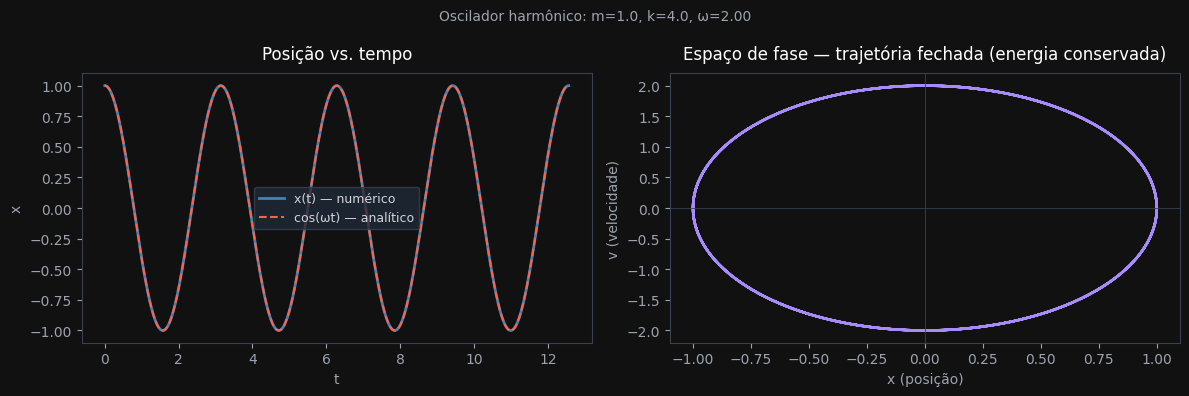

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ── Oscilador harmônico via Newton ───────────────────────────────────────────
# m*x'' = -k*x  →  sistema de 1ª ordem: [x' = v,  v' = -(k/m)*x]

m, k = 1.0, 4.0   # massa e constante de mola
omega = np.sqrt(k / m)

def oscilador(estado, t):
    x, v = estado
    return [v, -(k / m) * x]

t = np.linspace(0, 4 * np.pi, 500)
sol = odeint(oscilador, y0=[1.0, 0.0], t=t)   # x0=1, v0=0
x_analitico = np.cos(omega * t)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#111')
fig.patch.set_facecolor('#111')
for ax in axes:
    ax.set_facecolor('#111')
    ax.tick_params(colors='#9ca3af')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

# Trajetória temporal
axes[0].plot(t, sol[:, 0], color='steelblue', lw=2, label='x(t) — numérico')
axes[0].plot(t, x_analitico, color='tomato', lw=1.5, ls='--', label='cos(ωt) — analítico')
axes[0].set_xlabel('t', color='#9ca3af')
axes[0].set_ylabel('x', color='#9ca3af')
axes[0].set_title('Posição vs. tempo', color='white', pad=10)
axes[0].legend(fontsize=9, labelcolor='#d1d5db', facecolor='#1f2937', edgecolor='#374151')

# Espaço de fase (x, v)
axes[1].plot(sol[:, 0], sol[:, 1], color='#a78bfa', lw=1.8)
axes[1].set_xlabel('x (posição)', color='#9ca3af')
axes[1].set_ylabel('v (velocidade)', color='#9ca3af')
axes[1].set_title('Espaço de fase — trajetória fechada (energia conservada)', color='white', pad=10)
axes[1].axhline(0, color='#374151', lw=0.6)
axes[1].axvline(0, color='#374151', lw=0.6)

plt.suptitle(f'Oscilador harmônico: m={m}, k={k}, ω={omega:.2f}', color='#9ca3af', fontsize=10)
plt.tight_layout()
plt.show()

## 2. A formulação de Lagrange

*Esqueleto — expandir aqui*

Ideias centrais a desenvolver:

- **Princípio da ação mínima:** a trajetória real é a que extremiza $S = \int L \, dt$, onde $L = T - V$ (energia cinética menos potencial).
- `Equações de Euler-Lagrange`: $\frac{d}{dt}\frac{\partial L}{\partial \dot{q}} - \frac{\partial L}{\partial q} = 0$
- Vantagem: coordenadas generalizadas — o sistema se adapta à geometria do problema (ângulo para pêndulo, raio para movimento circular).
- Mostrar: recuperar o oscilador harmônico via Lagrangiana $L = \frac{1}{2}m\dot{x}^2 - \frac{1}{2}kx^2$.

## 3. A formulação de Hamilton

*Esqueleto — expandir aqui*

Ideias centrais a desenvolver:

- Substituir velocidade por `momento generalizado`: $p = \frac{\partial L}{\partial \dot{q}}$
- `Hamiltoniano`: $H(q, p) = p\dot{q} - L$ — geralmente igual à energia total $T + V$
- `Equações de Hamilton` (equações canônicas): $\dot{q} = \frac{\partial H}{\partial p}$, $\dot{p} = -\frac{\partial H}{\partial q}$
- O estado do sistema é um ponto no `espaço de fase` $(q, p)$. A evolução é um fluxo nesse espaço.
- `Colchetes de Poisson`: $\{f, g\} = \frac{\partial f}{\partial q}\frac{\partial g}{\partial p} - \frac{\partial f}{\partial p}\frac{\partial g}{\partial q}$
- Mostrar: para o oscilador, $H = \frac{p^2}{2m} + \frac{kx^2}{2}$ — elipses no espaço de fase.

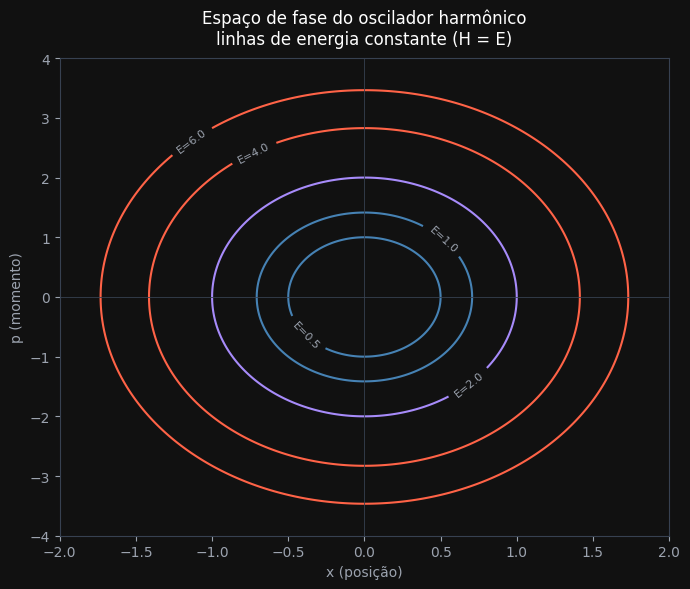

Cada elipse é uma trajetória possível com energia E fixada.
O sistema percorre a elipse com velocidade angular constante.
Isso é o Hamiltoniano clássico — a mesma estrutura que Schrödinger quantizou.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Espaço de fase hamiltoniano: linhas de energia constante ─────────────────
# H(x, p) = p²/2m + kx²/2 = E  →  elipses no espaço de fase

m, k = 1.0, 4.0
x = np.linspace(-2, 2, 400)
p = np.linspace(-4, 4, 400)
X, P = np.meshgrid(x, p)
H = P**2 / (2 * m) + k * X**2 / 2

fig, ax = plt.subplots(figsize=(7, 6), facecolor='#111')
fig.patch.set_facecolor('#111')
ax.set_facecolor('#111')
ax.tick_params(colors='#9ca3af')
for spine in ax.spines.values():
    spine.set_edgecolor('#374151')

levels = [0.5, 1.0, 2.0, 4.0, 6.0]
cs = ax.contour(X, P, H, levels=levels, colors=['steelblue', 'steelblue', '#a78bfa', 'tomato', 'tomato'],
                linewidths=1.5)
ax.clabel(cs, fmt='E=%.1f', colors='#9ca3af', fontsize=8)

ax.axhline(0, color='#374151', lw=0.6)
ax.axvline(0, color='#374151', lw=0.6)
ax.set_xlabel('x (posição)', color='#9ca3af')
ax.set_ylabel('p (momento)', color='#9ca3af')
ax.set_title('Espaço de fase do oscilador harmônico\nlinhas de energia constante (H = E)', color='white', pad=10)
plt.tight_layout()
plt.show()

print('Cada elipse é uma trajetória possível com energia E fixada.')
print('O sistema percorre a elipse com velocidade angular constante.')
print('Isso é o Hamiltoniano clássico — a mesma estrutura que Schrödinger quantizou.')

## 4. A ponte para a mecânica quântica

*Esqueleto — expandir aqui*

Ideias centrais a desenvolver:

- `Prescrição de quantização canônica`: substituir observáveis clássicos por operadores, colchetes de Poisson por comutadores:
  $$\{q, p\} = 1 \quad \longrightarrow \quad [\hat{q}, \hat{p}] = i\hbar$$
- O Hamiltoniano clássico $H(q, p)$ vira o `operador Hamiltoniano` $\hat{H}(\hat{q}, \hat{p})$.
- A equação de Hamilton $\dot{f} = \{f, H\}$ vira a equação de Heisenberg $i\hbar\dot{\hat{A}} = [\hat{A}, \hat{H}]$.
- Ponto central: a estrutura algébrica — a relação de comutação — é o que sobrevive na quantização. A geometria do espaço de fase muda; a álgebra se preserva.
- A receita não é única nem rigorosa para todos os sistemas, mas funciona para todos os casos relevantes deste projeto.

## Por que isso importa para algoritmos quânticos

O `operador Hamiltoniano` $\hat{H}$ é o objeto central de vários algoritmos quânticos:

- **Simulação hamiltoniana** (N-05): dado $\hat{H}$, implementar $e^{-i\hat{H}t}$ como circuito quântico.
- **Estimação de fase** (N-04): extrair autovalores de $\hat{H}$ (energias) via QPE.
- **VQE e QAOA**: otimizar parâmetros de circuito para minimizar $\langle \psi | \hat{H} | \psi \rangle$.

Sem a ponte Newton → Hamilton → Schrödinger, não é possível entender por que o operador Hamiltoniano é o que é, nem por que sua exponencial $e^{-i\hat{H}t}$ descreve evolução temporal.